<a href="https://colab.research.google.com/github/river-tech/khdl/blob/main/CIFAR10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification using CNN
### Midterm Project — Deep Learning Pipeline

**Dataset:** CIFAR-10 (60,000 images · 32×32 · RGB · 10 classes)  
**Framework:** TensorFlow / Keras  
**Model:** Custom CNN built from scratch

---
**Pipeline Steps:**
1. Import Libraries  
2. Load Dataset  
3. Preprocess Data  
4. Build CNN Model  
5. Compile Model  
6. Train Model  
7. Evaluate Model  
8. Classification Report  
9. Save Model  
10. Load Model  
11. Realtime Prediction  
12. Plot Training Results

## Section 1 — Import Libraries

In [ ]:
# ============================================================
# SECTION 1: IMPORT LIBRARIES
# ============================================================

import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

In [ ]:
# ---- Kiểm tra nội dung MyDrive (chạy nếu chưa biết tên thư mục) ----
import os
myDrive = '/content/drive/MyDrive'
print("Danh sách thư mục trong MyDrive:")
for item in sorted(os.listdir(myDrive)):
    full = os.path.join(myDrive, item)
    kind = "📁" if os.path.isdir(full) else "📄"
    print(f"  {kind}  {item}")

Danh sách thư mục trong MyDrive:
  📄   How to Make a Bot Join Google Meet.gdoc
  📄  1.gdoc
  📄  AI Meeting Copilot – Trợ lý cuộc họp Google Meet.gdoc
  📄  AI_Learning_Analytics_Report (2).xlsx
  📁  Anh Tiến
  📄  Bảng tính không có tiêu đề (1).gsheet
  📄  Bảng tính không có tiêu đề (2).gsheet
  📄  Bảng tính không có tiêu đề (3).gsheet
  📄  Bảng tính không có tiêu đề (4).gsheet
  📄  Bảng tính không có tiêu đề.gsheet
  📄  BlockAIthon .gsheet
  📁  CIFAR-10
  📄  Cấu trúc hệ thống.gdoc
  📄  Cấu trúc website.gdoc
  📁  Colab Notebooks
  📄  FLOW.gdoc
  📁  Google Earth
  📄  HỆ THỐNG QUẢN LÝ CỬA HÀNG.gdoc
  📄  Hoàng mealplan .gsheet
  📄  Hoàng mealplan.gdoc
  📄  Lâm mealplan .gsheet
  📄  Lâm wkplan.gsheet
  📄  Lịch tập bulking.gsheet
  📄  Lịch tập hà.gsheet
  📄  Martin PLAN .gdoc
  📄  Martin's plan.gdoc
  📄  Martin's wk plan w4.gsheet
  📄  Mẫu không có tiêu đề (1).gform
  📄  Mẫu không có tiêu đề.gform
  📄  Meal

## Section 2 — Load Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder: /content/drive/MyDrive/dataset
Raw dataset loaded
Images reshaped
x_train: (50000, 32, 32, 3)
y_train: (50000,)
x_test : (10000, 32, 32, 3)
y_test : (10000,)
Dataset ready for training


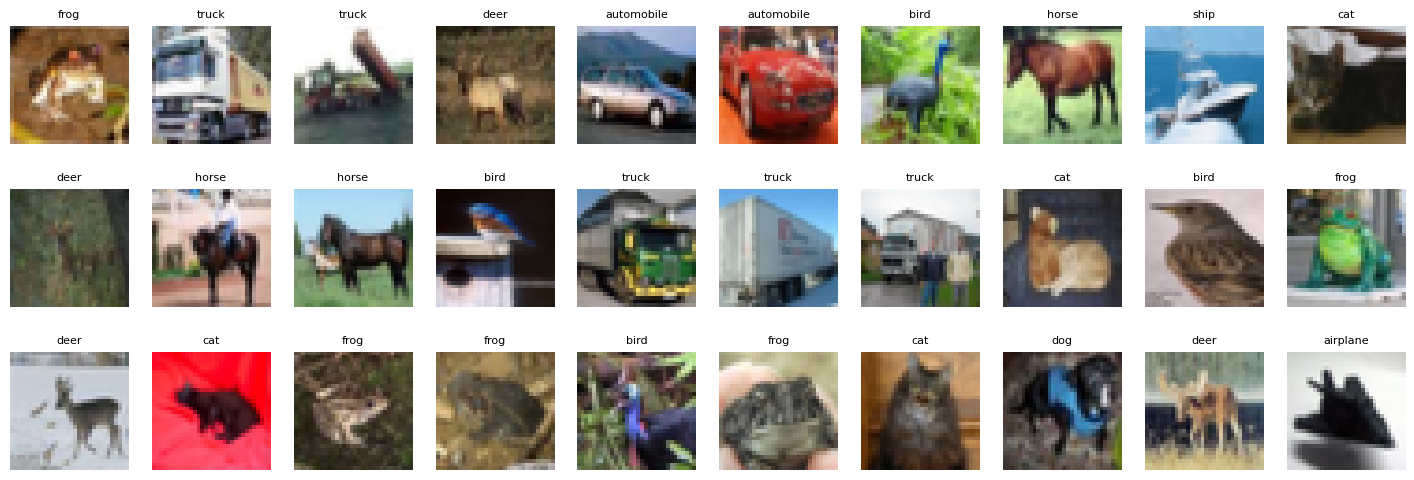

In [ ]:
# ============================================================
# SECTION 2: LOAD CIFAR10 DATASET FROM GOOGLE DRIVE
# ============================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# ---- Đường dẫn dataset ----
DATASET_PATH = "/content/drive/MyDrive/dataset"

print("Dataset folder:", DATASET_PATH)

# ------------------------------------------------------------
# Function load batch
# ------------------------------------------------------------
def load_batch(file):

    with open(file, 'rb') as fo:
        batch = pickle.load(fo, encoding='bytes')

    data = batch[b'data']
    labels = batch[b'labels']

    return data, labels


# ------------------------------------------------------------
# Load training batches
# ------------------------------------------------------------
xs = []
ys = []

for i in range(1,6):

    batch_file = os.path.join(DATASET_PATH, f"data_batch_{i}")
    data, labels = load_batch(batch_file)

    xs.append(data)
    ys.extend(labels)

x_train = np.concatenate(xs)
y_train = np.array(ys)

# ------------------------------------------------------------
# Load test batch
# ------------------------------------------------------------
test_file = os.path.join(DATASET_PATH, "test_batch")
x_test, y_test = load_batch(test_file)

y_test = np.array(y_test)

print("Raw dataset loaded")


# ------------------------------------------------------------
# Reshape images
# CIFAR10 format: (N, 3072)
# Convert → (N, 32, 32, 3)
# ------------------------------------------------------------

x_train = x_train.reshape(-1,3,32,32).transpose(0,2,3,1)
x_test  = x_test.reshape(-1,3,32,32).transpose(0,2,3,1)

print("Images reshaped")

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------
x_train = x_train / 255.0
x_test  = x_test / 255.0


# ------------------------------------------------------------
# One-hot encoding
# ------------------------------------------------------------
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train,10)
y_test  = to_categorical(y_test,10)

print("Dataset ready for training")


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]


# ------------------------------------------------------------
# Preview images
# ------------------------------------------------------------
fig, axes = plt.subplots(3,10, figsize=(18,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[np.argmax(y_train[i])], fontsize=8)
    ax.axis('off')

plt.show()

## Section 3 — Preprocess Data

In [ ]:
# ============================================================
# SECTION 3: PREPROCESS DATA
# ============================================================

# --- Step 1: Normalize pixel values to [0, 1] ---
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# --- Step 2: Convert integer labels to one-hot encoding ---
# e.g., class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

# --- Step 3: Print dataset shapes ---
print("After preprocessing:")
print(f"  x_train shape : {x_train.shape}   (50,000 training images, 32×32, RGB)")
print(f"  y_train shape : {y_train_ohe.shape}  (one-hot labels)")
print(f"  x_test  shape : {x_test.shape}   (10,000 test images,     32×32, RGB)")
print(f"  y_test  shape : {y_test_ohe.shape}  (one-hot labels)")
print(f"\nPixel value range : [{x_train.min():.1f}, {x_train.max():.1f}]")
print("Preprocessing complete ✅")

After preprocessing:
  x_train shape : (50000, 32, 32, 3)   (50,000 training images, 32×32, RGB)
  y_train shape : (50000, 10, 10)  (one-hot labels)
  x_test  shape : (10000, 32, 32, 3)   (10,000 test images,     32×32, RGB)
  y_test  shape : (10000, 10, 10)  (one-hot labels)

Pixel value range : [0.0, 0.0]
Preprocessing complete ✅


## Section 4 — Build CNN Model

In [ ]:
# ============================================================
# SECTION 4: BUILD CNN MODEL (from scratch — no pretrained weights)
# ============================================================
#
# Architecture:
#   Input          →  32×32×3
#   Conv2D(32)     →  ReLU  →  BatchNorm  →  MaxPooling  →  Dropout
#   Conv2D(64)     →  ReLU  →  BatchNorm  →  MaxPooling  →  Dropout
#   Conv2D(64)     →  ReLU  →  BatchNorm
#   Flatten
#   Dense(64)      →  ReLU  →  Dropout
#   Dense(10)      →  Softmax
# ============================================================

model = Sequential(name="CIFAR10_CNN")

# ----- Block 1 -----
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# ----- Block 2 -----
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# ----- Block 3 (recommended extra conv) -----
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())

# ----- Classifier head -----
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))   # 10 output classes

# Print architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,818 (1.22 MB)

 Trainable params: 319,498 (1.22 MB)

 Non-trainable params: 320 (1.25 KB)

## Section 5 — Compile Model

In [ ]:
# ============================================================
# SECTION 5: COMPILE MODEL
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),   # Adam optimizer
    loss='categorical_crossentropy',        # multi-class cross-entropy loss
    metrics=['accuracy']                    # track accuracy during training
)

print("Model compiled ✅")
print(f"  Optimizer : Adam  (lr=0.001)")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled ✅
  Optimizer : Adam  (lr=0.001)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


## Section 6 — Train Model

In [ ]:
# ============================================================
# SECTION 6: TRAIN MODEL
# ============================================================

from tensorflow.keras.utils import to_categorical

# ---- Ensure labels are one-hot encoded exactly once ----
# If labels are (N,1) or (N,) convert to (N,10)
if len(y_train.shape) == 1 or y_train.shape[-1] != 10:
    y_train_ohe = to_categorical(y_train, 10)
else:
    y_train_ohe = y_train

if len(y_test.shape) == 1 or y_test.shape[-1] != 10:
    y_test_ohe = to_categorical(y_test, 10)
else:
    y_test_ohe = y_test

# ---- Debug shapes before training ----
print("Shape check before training:")
print("x_train:", x_train.shape)
print("y_train:", y_train_ohe.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test_ohe.shape)
print()

# ---- Training parameters ----
EPOCHS     = 15
BATCH_SIZE = 32

print(f"Training for {EPOCHS} epochs, batch_size={BATCH_SIZE} …\n")

history = model.fit(
    x_train,
    y_train_ohe,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test_ohe),
    verbose=1
)

print("\nTraining complete ✅")

Shape check before training:
x_train: (50000, 32, 32, 3)
y_train: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)

Training for 15 epochs, batch_size=32 …

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 103ms/step - accuracy: 0.2664 - loss: 2.0296 - val_accuracy: 0.1830 - val_loss: 10.3120
Epoch 2/15
 257/1563 ━━━━━━━━━━━━━━━━━━━━ 2:01 93ms/step - accuracy: 0.4190 - loss: 1.5909

## Section 7 — Evaluate Model

In [ ]:
# ============================================================
# SECTION 7: EVALUATE MODEL
# ============================================================

test_loss, test_acc = model.evaluate(x_test, y_test_ohe, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print("=" * 40)

## Section 8 — Classification Report (Precision / Recall / F1-score)

In [ ]:
# ============================================================
# SECTION 8: CLASSIFICATION REPORT
# ============================================================

# Get raw probability predictions for every test image
y_pred_probs = model.predict(x_test, verbose=0)

# Convert probabilities → predicted class index (0–9)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot true labels → integer class index
y_true_classes = np.argmax(y_test_ohe, axis=1)

# Print precision, recall, F1-score per class
print("Classification Report:")
print("=" * 60)
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names
))
print("=" * 60)

## Section 9 — Save Model

In [ ]:
# ============================================================
# SECTION 9: SAVE MODEL
# ============================================================

MODEL_PATH = "cifar10_model.h5"

model.save(MODEL_PATH)

print(f"Model saved to '{MODEL_PATH}' ✅")

## Section 10 — Load Model

In [ ]:
# ============================================================
# SECTION 10: LOAD MODEL
# ============================================================

from tensorflow.keras.models import load_model

loaded_model = load_model("cifar10_model.h5")

print("Model loaded from 'cifar10_model.h5' ✅")

# Quick sanity-check: re-evaluate with the loaded model
_, loaded_acc = loaded_model.evaluate(x_test, y_test_ohe, verbose=0)
print(f"Loaded model — Test Accuracy: {loaded_acc * 100:.2f}%")

## Section 11 — Realtime Image Prediction

> **How to use (Google Colab):**  
> Run this cell → a **Choose Files** button will appear → upload any image from your local machine → the model will resize it to 32×32, predict the class, and display the result.

In [ ]:
# ============================================================
# SECTION 11: REALTIME IMAGE PREDICTION
# ============================================================
# This cell is designed for Google Colab.
# If running locally, replace the upload block with:
#   img_path = "/path/to/your/image.jpg"
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.utils import load_img, img_to_array

# --- Class labels ---
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ----------------------------------------------------------------
# Step 1: Upload image  (Colab file upload widget)
# ----------------------------------------------------------------
try:
    from google.colab import files
    print("📂 Please upload an image file …")
    uploaded = files.upload()                         # opens file picker
    img_path = list(uploaded.keys())[0]               # path of first uploaded file
    print(f"Uploaded: {img_path}")

except ImportError:
    # ---- Fallback: use a random test image when NOT in Colab ----
    print("⚠️  google.colab not available — using a random test image instead.")
    idx = np.random.randint(0, len(x_test))
    # Save that test image temporarily so the rest of the code is identical
    img_array_uint8 = (x_test[idx] * 255).astype(np.uint8)
    from PIL import Image
    tmp_img = Image.fromarray(img_array_uint8)
    img_path = "sample_test_image.png"
    tmp_img.save(img_path)
    print(f"Using test image index {idx}  (true label: {class_names[y_true_classes[idx]]})")

# ----------------------------------------------------------------
# Step 2: Load & resize to 32×32
# ----------------------------------------------------------------
img_original = load_img(img_path)                     # PIL Image (original size)
img_resized  = load_img(img_path, target_size=(32, 32))

# ----------------------------------------------------------------
# Step 3: Normalize pixel values
# ----------------------------------------------------------------
img_array = img_to_array(img_resized) / 255.0         # shape: (32, 32, 3)
img_input = np.expand_dims(img_array, axis=0)         # shape: (1, 32, 32, 3)

# ----------------------------------------------------------------
# Step 4: Predict class using the loaded model
# ----------------------------------------------------------------
predictions   = loaded_model.predict(img_input, verbose=0)[0]  # shape: (10,)
pred_idx      = int(np.argmax(predictions))
pred_label    = class_names[pred_idx]
confidence    = float(predictions[pred_idx]) * 100

# ----------------------------------------------------------------
# Step 5: Display result
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Realtime Prediction", fontsize=14, fontweight='bold')

# --- Left: input image (original size) ---
axes[0].imshow(img_original)
axes[0].set_title("Input Image", fontsize=11)
axes[0].axis('off')

# --- Right: class probability bar chart ---
colors = ['#d9534f' if i == pred_idx else '#5bc0de' for i in range(10)]
axes[1].barh(class_names, predictions * 100, color=colors)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title("Class Probabilities", fontsize=11)
axes[1].set_xlim(0, 100)
for i, v in enumerate(predictions * 100):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

highlight = mpatches.Patch(color='#d9534f', label='Predicted class')
axes[1].legend(handles=[highlight], loc='lower right')

plt.tight_layout()
plt.show()

print("=" * 40)
print(f"  Prediction : {pred_label}")
print(f"  Confidence : {confidence:.1f}%")
print("=" * 40)

## Section 12 — Plot Training Results

In [ ]:
# ============================================================
# SECTION 12: PLOT TRAINING RESULTS
# ============================================================

epochs_range = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Results — CIFAR-10 CNN", fontsize=14, fontweight='bold')

# ---- Plot 1: Accuracy ----
axes[0].plot(epochs_range, history.history['accuracy'],     'b-o', label='Training Accuracy')
axes[0].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(epochs_range)

# ---- Plot 2: Loss ----
axes[1].plot(epochs_range, history.history['loss'],     'b-o', label='Training Loss')
axes[1].plot(epochs_range, history.history['val_loss'], 'r-o', label='Validation Loss')
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'training_results.png' ✅")